In [1]:
import numpy as np
import os
import json

data_dir = os.path.join(os.getcwd(), "data")
matrices_path = os.path.join(data_dir, "matrices.npy")
matrices = np.load(matrices_path, allow_pickle=True)

query_clusters_path = os.path.join(os.getcwd(), "data_for_git/all_query_clusters.jsonl")
query_clusters = []
with open(query_clusters_path, "r") as f:
    for line in f:
        query_clusters.append(json.loads(line))


In [ ]:
def get_cluster_type(cluster):
    return len(set([f["from_sequence"] for f in cluster["atomic_facts"]]))


def merge_clusters(query, matrix, idx1, idx2):
    """
    Merge clusters idx1 and idx2 in-place into the chosen target.
    - Higher type wins; on type tie, higher total degree (in+out, any label) wins;
      on tie, idx1 wins as target.
    - Facts from the source are appended to the target.
    - Entailment rows/cols are merged by elementwise max across labels.
    - Removes the source cluster and corresponding row/col from matrix.
    Returns (target_idx, matrix) where target_idx is the new index of the merged cluster.
    """
    clusters = query["clusters"]
    n = len(clusters)
    assert matrix.shape[0] == n and matrix.shape[1] == n, "matrix size mismatch"

    def cluster_type(i):
        return len(set(f["from_sequence"] for f in clusters[i]["atomic_facts"]))

    def degree(i):
        # total in+out edges where any label > 0
        out_deg = np.sum(np.any(matrix[i] > 0, axis=1))
        in_deg  = np.sum(np.any(matrix[:, i, :] > 0, axis=1))
        return int(out_deg + in_deg)

    t, s = idx1, idx2
    t_type, s_type = cluster_type(t), cluster_type(s)
    if s_type > t_type:
        t, s = s, t
    elif s_type == t_type:
        if degree(s) > degree(t):
            t, s = s, t
        # if still tied, keep t as is (idx1 wins)

    # 1) Merge facts
    clusters[t]["atomic_facts"].extend(clusters[s]["atomic_facts"])

    # 2) Merge matrix rows/cols by max per label
    for lbl in range(matrix.shape[2]):
        matrix[t, :, lbl] = np.maximum(matrix[t, :, lbl], matrix[s, :, lbl])
        matrix[:, t, lbl] = np.maximum(matrix[:, t, lbl], matrix[:, s, lbl])
    # No self-edge
    matrix[t, t, :] = 0

    # 3) Remove source row/col from matrix
    matrix = np.delete(matrix, s, axis=0)
    matrix = np.delete(matrix, s, axis=1)

    # 4) Remove source cluster
    clusters.pop(s)
    return matrix

def remove_edges(matrix, u, v):
    matrix[u, v, :] = 0
    matrix[v, u, :] = 0
    return matrix





merge_jobs = []
merge_jobs.append({"n": 18, "cluster1_idx": 88, "cluster2_idx": 65})
merge_jobs.append({"n": 273, "cluster1_idx": 76, "cluster2_idx": 111})
merge_jobs.append({"n": 411, "cluster1_idx": 54, "cluster2_idx": 80})
merge_jobs.append({"n": 421, "cluster1_idx": 203, "cluster2_idx": 93})
merge_jobs.append({"n": 421, "cluster1_idx": 32, "cluster2_idx": 162})
merge_jobs.append({"n": 519, "cluster1_idx": 64, "cluster2_idx": 84})
merge_jobs.append({"n": 528, "cluster1_idx": 106, "cluster2_idx": 24})
# merge_jobs.append({"n": 585, "cluster1_idx": 36, "cluster2_idx": 12})
merge_jobs.append({"n": 589, "cluster1_idx": 28, "cluster2_idx": 2})
merge_jobs.append({"n": 673, "cluster1_idx": 49, "cluster2_idx": 71})

remove_edges(matrices[585], 36, 12)

for job in merge_jobs:
    n = job["n"]
    cluster1_idx = job["cluster1_idx"]
    cluster2_idx = job["cluster2_idx"]
    matrices[n] = merge_clusters(query_clusters[n], matrices[n], cluster1_idx, cluster2_idx)



In [11]:
# calculate and store average logprob of each cluster
for n in range(len(matrices)):
    for cluster in query_clusters[n]["clusters"]:
        cluster["avg_logprob"] = np.mean([f["logprob"] for f in cluster["atomic_facts"]])




In [3]:
from typing import List
def make_adj_weights_from_scores(scores, threshold=0.6, label_idx=2):
    d = scores.shape[0]
    adj = []
    weights = []
    for i in range(d):
        mask = scores[i, :, label_idx] >= threshold
        neighbors = np.where(mask)[0].tolist()
        w = scores[i, neighbors, label_idx].tolist()
        adj.append(neighbors)
        weights.append(w)
    return adj, weights




adj_lists = []
weight_lists = []
for matrix in matrices:
    adj, weights = make_adj_weights_from_scores(matrix)
    adj_lists.append(adj)
    weight_lists.append(weights)


In [4]:
def find_cycle_min_edge(adj, weights):
    """
    adj[u]: list of neighbor nodes
    weights[u]: list of edge weights aligned with adj[u]
    Returns (is_dag, min_edge, min_weight)
    """
    n = len(adj)
    state = [0] * n          # 0=unvisited, 1=visiting, 2=done
    parent = [-1] * n
    parent_edge_w = [None] * n  # weight of edge from parent->node
    min_edge = None
    min_w = None
    cycle_found = False

    def dfs(u):
        nonlocal cycle_found, min_edge, min_w
        state[u] = 1
        for v, w_uv in zip(adj[u], weights[u]):
            if state[v] == 0:
                parent[v] = u
                parent_edge_w[v] = w_uv
                dfs(v)
                if cycle_found:
                    return
            elif state[v] == 1:  # back-edge => cycle
                cycle_found = True
                # reconstruct cycle u -> ... -> v
                path_edges = []
                x = u
                while x != v and x != -1:
                    p = parent[x]
                    if p == -1:
                        break
                    path_edges.append((p, x, parent_edge_w[x]))
                    x = p
                path_edges.append((u, v, w_uv))  # include back-edge
                # pick min-weight edge on this cycle
                for _, __, w in path_edges:
                    if min_w is None or w < min_w:
                        min_w = w
                        # store just the endpoints for return
                        min_edge = (_ , __) if w == min_w else min_edge
                return
        state[u] = 2

    for u in range(n):
        if state[u] == 0:
            dfs(u)
        if cycle_found:
            break

    return (not cycle_found, min_edge, min_w)

In [5]:
import numpy as np
import torch


n_verify = 0
adj = adj_lists[n_verify]
weight = weight_lists[n_verify]
d = matrices[n_verify].shape[0]
print(find_cycle_min_edge(adj, weight))

to_investigate = []
for n in range(len(matrices)):
    adj = adj_lists[n]
    weight = weight_lists[n]
    d = matrices[n].shape[0]
    is_dag, min_edge, min_w = find_cycle_min_edge(adj, weight)
    if not is_dag:
        print(n)
        print("number of clusters: ", len(query_clusters[n]["clusters"]))
        print("representative: ", query_clusters[n]["clusters"][min_edge[0]]["representative"]["atomic_fact"])
        print(min_edge)
        print(min_w)
        to_investigate.append({"n": n, "representative": query_clusters[n]["clusters"][min_edge[0]]["representative"]["atomic_fact"]})
        # break


(True, None, None)
421
number of clusters:  256
representative:  – Patoranking’s music blends Afro‑beat, reggae, and dancehall influences.
(32, 161)
0.9353751540184021


In [6]:
import graphviz

def visualize_hierarchy(matrix, clusters, thr=0.5):
    dot = graphviz.Digraph(comment="My Hierarchical DAG", graph_attr={"rankdir": "TB"})
    reps = [c["representative"] for c in clusters]

    # create nodes with safe IDs, display text in labels
    for i, rep in enumerate(reps):
        dot.node(f"n{i}", label=rep["atomic_fact"])

    # edges by entailment score
    for i, rep in enumerate(reps):
        for j, other_rep in enumerate(reps):
            if i == j:
                continue
            if matrix[i][j][2] > thr:
                dot.edge(f"n{j}", f"n{i}",
                         label=f"{matrix[i][j][2]:.2f} ({matrix[j][i][2]:.2f})")
    return dot

for investigate in to_investigate:
    n = investigate["n"]
    print(investigate["representative"])
    dot = visualize_hierarchy(matrices[n], query_clusters[n]["clusters"])
    dot.format = "svg"
    dot.render(str(n), format="svg", cleanup=True, directory=os.path.join(os.getcwd(), "hierarchy_visualizations"))

– Patoranking’s music blends Afro‑beat, reggae, and dancehall influences.


In [ ]:
def count_descendants(adj):
    """
    adj: list of lists, adj[u] = direct children of u
    returns: list counts[u] = number of descendants (any depth) of u
    """
    n = len(adj)
    memo = [None] * n

    def dfs(u):
        if memo[u] is not None:
            return memo[u]
        seen = set()
        stack = list(adj[u])
        while stack:
            v = stack.pop()
            if v in seen:
                continue
            seen.add(v)
            stack.extend(adj[v])
        memo[u] = len(seen)
        return memo[u]

    return [dfs(u) for u in range(n)]

def reverse_dag(adj):
    inv_adj = [[] for _ in range(len(adj))]
    for u, children in enumerate(adj):
        for v in children:
            inv_adj[v].append(u)
    return inv_adj

def count_ancestors(adj):
    return count_descendants(reverse_dag(adj))



63338


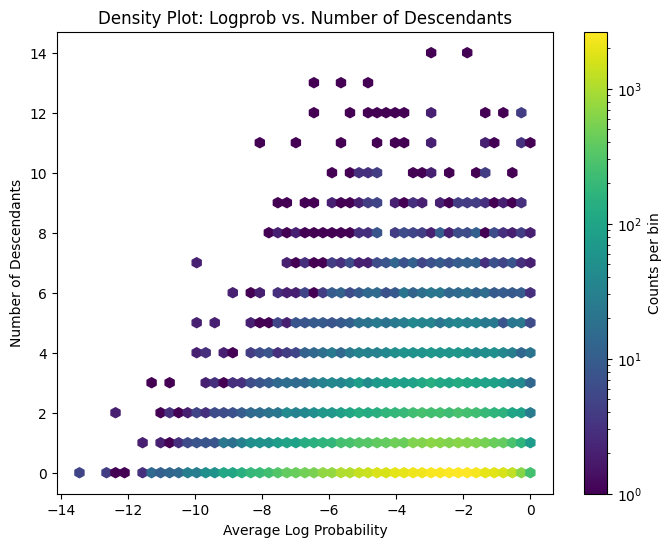

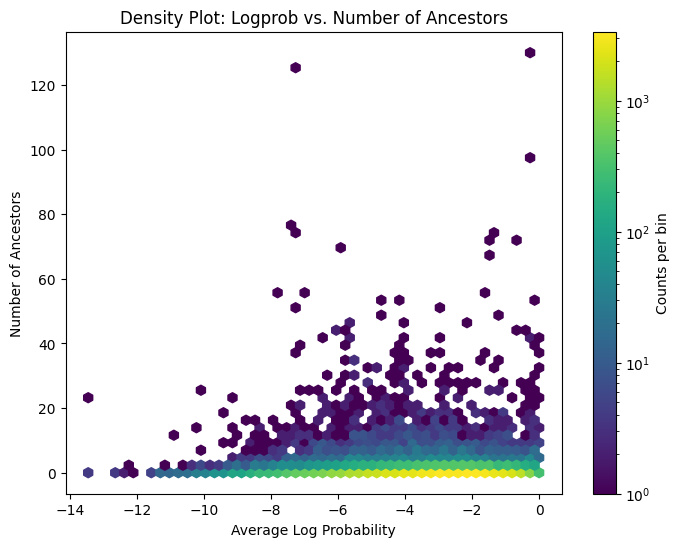

In [32]:
import matplotlib.pyplot as plt
all_logprobs = []
all_descendants = []
all_ancestors = []
for query_n in range(len(matrices)):
    adj = adj_lists[query_n]
    n_descendants = count_descendants(adj)
    n_ancestors = count_ancestors(adj)
    type_n = 1
    # look at all the clusters with type n and record their average logprob and 
    # number of children, plot the correlation between the two
    logprobs = []
    descendants = []
    ancestors = []
    for cluster, descendant_count, ancestor_count in zip(query_clusters[query_n]["clusters"], n_descendants, n_ancestors):
        if cluster["type"] != type_n:
            continue
        logprob = cluster["avg_logprob"]
        logprobs.append(logprob)
        descendants.append(descendant_count)
        ancestors.append(ancestor_count)
    all_logprobs.extend(logprobs)
    all_descendants.extend(descendants)
    all_ancestors.extend(ancestors)

print(len(all_logprobs))

# plot density of points (hexbin) instead of raw scatter plot with log scale coloring
plt.figure(figsize=(8, 6))
hb = plt.hexbin(all_logprobs, all_descendants, gridsize=50, cmap='viridis', mincnt=1, bins='log')
plt.colorbar(hb, label='Counts per bin')
plt.xlabel('Average Log Probability')
plt.ylabel('Number of Descendants')
plt.title('Density Plot: Logprob vs. Number of Descendants')
plt.show()


plt.figure(figsize=(8, 6))
hb = plt.hexbin(all_logprobs, all_ancestors, gridsize=50, cmap='viridis', mincnt=1, bins='log')
plt.colorbar(hb, label='Counts per bin')
plt.xlabel('Average Log Probability')
plt.ylabel('Number of Ancestors')
plt.title('Density Plot: Logprob vs. Number of Ancestors')
plt.show()



In [ ]:
def find_sequence_ids(query_clusters):
    sequence_ids = set()
    for cluster in query_clusters:
        for fact in cluster["atomic_facts"]:
            sequence_ids.add(fact["from_sequence"])
    return list(sequence_ids)


# check that all queries have at least one fact from each sequence
queries_without_5_sequences = []
for i, query in enumerate(query_clusters):
    sequence_ids = find_sequence_ids(query["clusters"])
    if len(sequence_ids) < 5:
        queries_without_5_sequences.append(i)

def include_in_folds(query):
    sequence_ids = find_sequence_ids(query["clusters"])
    return len(sequence_ids) >= 5

# for query in query_clusters:
#     sequence_ids = find_sequence_ids(query["clusters"])
#     if len(sequence_ids) > 1:
#         print(query["query"])
#         break
include_in_folds = [query for query in query_clusters if include_in_folds(query)]
print(f"Number of excluded queries: {len(query_clusters)-len(include_in_folds)}")

Number of excluded queries: 2


In [ ]:
from collections import deque

def entailment2weight_sigmoid(entailment_score: float) -> float:
    bias = 0.5
    scale = 15
    return 1 / (1 + np.exp(-(entailment_score - bias) * scale))


def get_sequence_presence(cluster):
    sequence_ids = find_sequence_ids(cluster)
    return [1 if seq_id in sequence_ids else 0 for seq_id in query["sequence_ids"]]

def propagate_presence(adj, weights, presences):
    """
    adj[u]: list of neighbors (u -> v)
    weights[u]: list of edge weights aligned with adj[u]
    presences: list of arrays/lists, presences[u][k] = presence of node u in seq k
    Returns a new list of presence vectors after propagation.
    """
    n = len(adj)
    # copy to avoid mutating caller data
    pres = [np.array(p, dtype=float) for p in presences]

    # topological order (assumes DAG)
    indeg = [0]*n
    for u, nbrs in enumerate(adj):
        for v in nbrs: indeg[v] += 1
    q = deque([i for i,d in enumerate(indeg) if d==0])
    topo = []
    while q:
        u = q.popleft()
        topo.append(u)
        for v in adj[u]:
            indeg[v] -= 1
            if indeg[v] == 0:
                q.append(v)

    # propagate along topo order
    for u in topo:
        pu = pres[u]
        for v, w in zip(adj[u], weights[u]):
            w_sig = entailment2weight_sigmoid(w)
            pres[v] = np.maximum(pres[v], pu * w_sig)

    return pres

presence_lists = []
for query in include_in_folds:
    query_presence_lists = []
    for cluster in query["clusters"]:
        query_presence_lists.append(get_sequence_presence(cluster))
    presence_lists.append(query_presence_lists)



In [ ]:
import copy
# store the sequence ids in the query clusters
for query in query_clusters:
    query["sequence_ids"] = find_sequence_ids(query)

def make_folds_with_adj_weights(query, adj, weights, sequence_ids):
    """
    query: original query dict with clusters
    adj: list[list[int]] neighbors per node
    weights: list[list[float]] edge weights aligned with adj
    sequence_ids: iterable of sequence_ids to leave out one at a time

    Returns: list of folds, each:
        {
          "query": pruned_query,
          "adj":   pruned_adj,
          "weights": pruned_weights
        }
    """
    folds = []
    for seq_id in sequence_ids:
        q_copy = copy.deepcopy(query)

        # 1) Filter clusters and facts
        kept_clusters = []
        keep_mask = []  # original indices that survive
        for idx, cluster in enumerate(q_copy["clusters"]):
            filtered_facts = [f for f in cluster["atomic_facts"]
                              if f.get("from_sequence") != seq_id]
            if filtered_facts:
                cluster["atomic_facts"] = filtered_facts
                kept_clusters.append(cluster)
                keep_mask.append(idx)
        q_copy["clusters"] = kept_clusters

        # 2) Remap adjacency and weights
        old_to_new = {old: new for new, old in enumerate(keep_mask)}
        pruned_adj = []
        pruned_weights = []
        for old_u in keep_mask:
            new_neighbors = []
            new_w = []
            for v, w in zip(adj[old_u], weights[old_u]):
                if v in old_to_new:          # keep only surviving nodes
                    new_neighbors.append(old_to_new[v])
                    new_w.append(w)
            pruned_adj.append(new_neighbors)
            pruned_weights.append(new_w)

        folds.append({"query": q_copy, "adj": pruned_adj, "weights": pruned_weights})
    return folds

folds = make_folds_with_adj_weights(query_clusters, adj_lists[0]["adj"], query_clusters[0]["sequence_ids"])

